In [37]:
import torchmetrics
import torchvision
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

In [38]:
# from pathlib import Path

# img_path = Path(r'C:\Users\user\Desktop\div\others\test\shekil.png')
# img_tensor = torchvision.io.read_image(img_path)

# print(img_tensor.dtype, img_tensor.shape)

# plt.imshow(img_tensor.permute(1, 2, 0))
# plt.show()

<class 'list'> 2
(427, 640, 3) (427, 640, 3)
uint8 (2, 427, 640, 3)


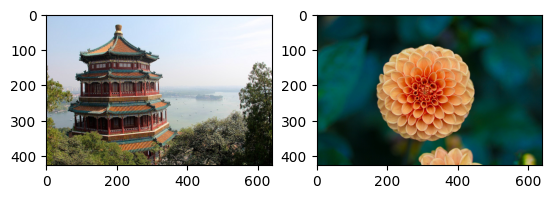

In [39]:
from sklearn.datasets import load_sample_images
import numpy as np

sample_images = load_sample_images()["images"]
print(type(sample_images), len(sample_images))
print(sample_images[0].shape, sample_images[1].shape)

sample_images = np.stack(sample_images)
print(sample_images.dtype, sample_images.shape)

fig,axs = plt.subplots(1, 2)
axs[0].imshow(sample_images[0, ...])
axs[1].imshow(sample_images[1, ...])
plt.show()

In [40]:
sample_images = torch.tensor(sample_images, dtype=torch.float32) / 255
sample_images_permuted = sample_images.permute(0, 3, 1, 2)

print(sample_images_permuted.dtype, sample_images_permuted.shape)

torch.float32 torch.Size([2, 3, 427, 640])


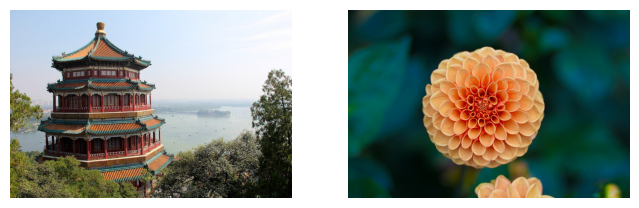

In [41]:
def plot_image(image):
    plt.imshow(image.permute(1, 2, 0))
    plt.axis("off")

plt.figure(figsize=(8, 4))
for index, image in enumerate(sample_images_permuted):
    plt.subplot(1, 2, index + 1)
    plot_image(image)

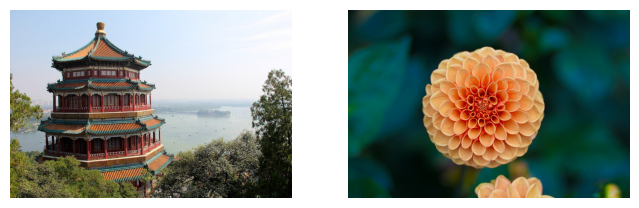

In [42]:
plt.figure(figsize=(8, 4))
for index, image in enumerate(sample_images_permuted):
    plt.subplot(1, 2, index + 1)
    plot_image(image)

In [43]:
import torchvision
import torchvision.transforms.v2 as T

cropped_images = T.CenterCrop((70, 120))(sample_images_permuted)
cropped_images.shape

torch.Size([2, 3, 70, 120])

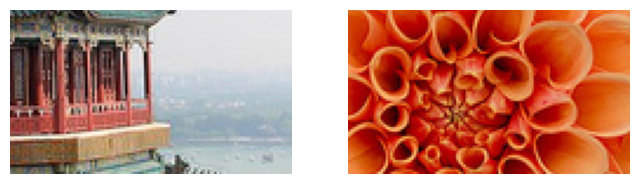

In [44]:
plt.figure(figsize=(8, 4))
plt.subplot(1, 2, 1)
plot_image(cropped_images[0])
plt.subplot(1, 2, 2)
plot_image(cropped_images[1])

In [45]:
import torch.nn as nn

torch.manual_seed(42)
conv_layer = nn.Conv2d(in_channels=3, out_channels=32, kernel_size=7)
print(cropped_images.shape)
print(conv_layer.weight.shape, conv_layer.padding,  conv_layer.stride)
fmaps = conv_layer(cropped_images)
print(fmaps.shape)

torch.Size([2, 3, 70, 120])
torch.Size([32, 3, 7, 7]) (0, 0) (1, 1)
torch.Size([2, 32, 64, 114])


# calculation of the output size

$$
\text{Output Height} = \frac{H_I - H_K + 2P}{S} + 1
$$

$$
\text{Output Width} = \frac{W_I - W_K + 2P}{S} + 1
$$

In [46]:
H_i, W_i = cropped_images.shape[-2:]
H_k, W_k = conv_layer.weight.shape[-2:]
P = conv_layer.padding[-2]
S = conv_layer.stride[-2]

H_o = (H_i - H_k + 2 * P) / S + 1
W_o = (W_i - W_k + 2 * P) / S + 1

H_o, W_o


(64.0, 114.0)

# calculation of the feature map

## 1st image, 1st fmap, 1st value

In [47]:
print(cropped_images[0, ...].shape)
window_3d = cropped_images[0, :, :7, :7]
print(window_3d.shape)

print(conv_layer.weight.shape)
kernel3d_weights = conv_layer.weight.data[0, ...]
kernel3d_biases = conv_layer.bias.data[0]
print(kernel3d_weights.shape, kernel3d_biases.shape)

torch.Size([3, 70, 120])
torch.Size([3, 7, 7])
torch.Size([32, 3, 7, 7])
torch.Size([3, 7, 7]) torch.Size([])


In [48]:
torch.sum(window_3d * kernel3d_weights) + kernel3d_biases

tensor(-0.1800)

In [49]:
fmaps[0, 0, ...]

tensor([[-0.1800, -0.0474, -0.0864,  ..., -0.5462, -0.5453, -0.5485],
        [-0.1327, -0.0746, -0.0779,  ..., -0.5462, -0.5477, -0.5488],
        [-0.1637, -0.0655, -0.1306,  ..., -0.5417, -0.5418, -0.5434],
        ...,
        [-0.0321, -0.0645, -0.0578,  ..., -0.5118, -0.4954, -0.4886],
        [-0.0207, -0.0016,  0.0225,  ..., -0.5112, -0.5027, -0.4986],
        [ 0.1434,  0.1303,  0.1060,  ..., -0.5101, -0.4955, -0.5002]],
       grad_fn=<SelectBackward0>)

## 1st image, all fmaps, 1st value

In [50]:
print(cropped_images[0, ...].shape)
window_3d = cropped_images[0:1, ..., :7, :7]
print(window_3d.shape)

print(conv_layer.weight.shape)
kernel3d_weights = conv_layer.weight.data
kernel3d_biases = conv_layer.bias.data
print(kernel3d_weights.shape, kernel3d_biases.shape)

torch.Size([3, 70, 120])
torch.Size([1, 3, 7, 7])
torch.Size([32, 3, 7, 7])
torch.Size([32, 3, 7, 7]) torch.Size([32])


In [51]:
fmaps_1st_value = (window_3d * kernel3d_weights).sum(dim=(1, 2, 3)) + kernel3d_biases

print(fmaps_1st_value.shape)
fmaps_1st_value

torch.Size([32])


tensor([-0.1800, -0.0895, -0.2501,  0.2870, -0.1033, -0.0494, -0.0716,  0.1195,
         0.0796,  0.0397,  0.0610, -0.0450,  0.0240, -0.1144,  0.2558, -0.1752,
         0.1470,  0.2807, -0.0709, -0.0365,  0.0283,  0.1976, -0.1139, -0.1695,
         0.0302, -0.1421,  0.0924,  0.2340, -0.1881,  0.0174, -0.6114, -0.0271])

In [52]:
fmaps[0, :, 0, 0]

tensor([-0.1800, -0.0895, -0.2501,  0.2870, -0.1033, -0.0494, -0.0716,  0.1195,
         0.0796,  0.0397,  0.0610, -0.0450,  0.0240, -0.1144,  0.2558, -0.1752,
         0.1470,  0.2807, -0.0709, -0.0365,  0.0283,  0.1976, -0.1139, -0.1695,
         0.0302, -0.1421,  0.0924,  0.2340, -0.1881,  0.0174, -0.6114, -0.0271],
       grad_fn=<SelectBackward0>)

## all images, all fmaps, all values

In [53]:
import torch.nn.functional as F

F.conv2d(
    cropped_images, 
    conv_layer.weight.data, 
    conv_layer.bias.data, 
    stride=1, 
    padding=0
).shape

torch.Size([2, 32, 64, 114])

torch.Size([2, 32, 64, 114])


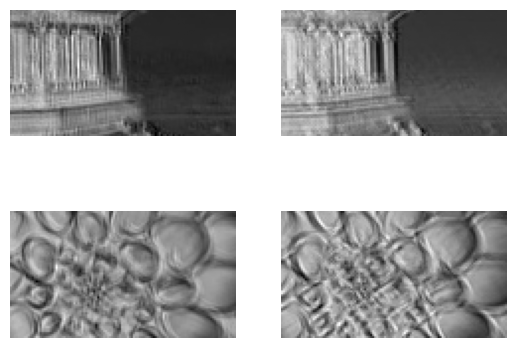

In [54]:
print(fmaps.shape)

for image_idx in (0, 1):
    for fmap_idx in (0, 1):
        plt.subplot(2, 2, image_idx * 2 + fmap_idx + 1)
        plt.imshow(fmaps[image_idx, fmap_idx].detach(), cmap="gray")
        plt.axis("off")

plt.show()

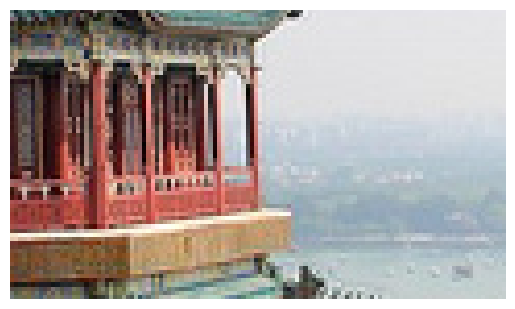

In [55]:
plot_image(cropped_images[0])

torch.Size([2, 3, 70, 120])
torch.Size([2, 3, 35, 60])


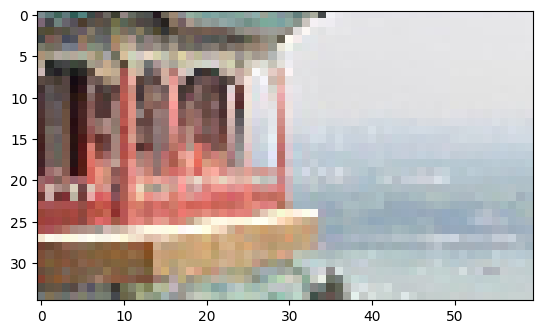

In [56]:
max_pool = nn.MaxPool2d(kernel_size=2)
output_max = max_pool(cropped_images)
print(cropped_images.shape)
print(output_max.shape)
plt.imshow(output_max[0].permute(1, 2, 0))

torch.Size([2, 3, 70, 120])
torch.Size([2, 3, 35, 60])


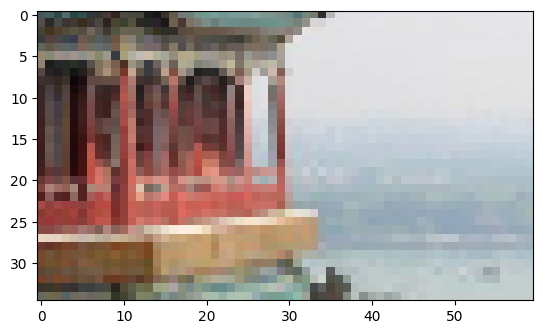

In [57]:
avg_pool = nn.AvgPool2d(kernel_size=2)
output_avg = avg_pool(cropped_images)
print(cropped_images.shape)
print(output_avg.shape)
plt.imshow(output_avg[0].permute(1, 2, 0))

In [58]:
global_avg_pool = nn.AvgPool2d(kernel_size=(70, 120))
output = global_avg_pool(cropped_images)
output.shape

torch.Size([2, 3, 1, 1])

In [59]:
global_avg_pool = nn.AdaptiveAvgPool2d(output_size=1)
output = global_avg_pool(cropped_images)
# output = cropped_images.mean(dim=(2, 3), keepdim=True)
output.shape

torch.Size([2, 3, 1, 1])

In [60]:
import torchvision
import torchvision.transforms.v2 as T

toTensor = T.Compose([
    T.ToImage(), 
    T.ToDtype(torch.float32, scale=True)
])

train_and_valid_data = torchvision.datasets.FashionMNIST(
    root="data", train=True, download=True, transform=toTensor)
test_data = torchvision.datasets.FashionMNIST(
    root="data", train=False, download=True, transform=toTensor)

torch.manual_seed(42)
train_data, valid_data = torch.utils.data.random_split(train_and_valid_data, [55_000, 5_000])

from torch.utils.data import DataLoader

torch.manual_seed(42)
train_loader = DataLoader(train_data, batch_size=32, shuffle=True)
valid_loader = DataLoader(valid_data, batch_size=32)
test_loader = DataLoader(test_data, batch_size=32)

In [61]:
if torch.cuda.is_available():
    device = "cuda"
elif torch.backends.mps.is_available():
    device = "mps"
else:
    device = "cpu"

device

# from functools import partial

# torch.manual_seed(42)  # extra code – ensure reproducibility
# DefaultConv2d = partial(nn.Conv2d, kernel_size=3, padding="same")
# model = nn.Sequential(
#     DefaultConv2d(in_channels=1, out_channels=64, kernel_size=7), nn.ReLU(),
#     nn.MaxPool2d(kernel_size=2),
#     DefaultConv2d(in_channels=64, out_channels=128), nn.ReLU(),
#     DefaultConv2d(in_channels=128, out_channels=128), nn.ReLU(),
#     nn.MaxPool2d(kernel_size=2),
#     DefaultConv2d(in_channels=128, out_channels=256), nn.ReLU(),
#     DefaultConv2d(in_channels=256, out_channels=256), nn.ReLU(),
#     nn.MaxPool2d(kernel_size=2),
#     nn.Flatten(),
#     nn.Linear(in_features=2304, out_features=128), nn.ReLU(),
#     nn.Dropout(0.5),
#     nn.Linear(in_features=128, out_features=64), nn.ReLU(),
#     nn.Dropout(0.5),
#     nn.Linear(in_features=64, out_features=10),
# ).to(device)

model = nn.Sequential(
    nn.Conv2d(in_channels=1, out_channels=64, kernel_size=7, padding="same"), # [32, 64, 28, 28]
    nn.ReLU(),
    nn.MaxPool2d(kernel_size=2), # [32, 64, 14, 14]
    nn.Conv2d(in_channels=64, out_channels=128, kernel_size=3, padding="same"), # [32, 128, 14, 14]
    nn.ReLU(),
    nn.Conv2d(in_channels=128, out_channels=128, kernel_size=3, padding="same"), # [32, 128, 14, 14]
    nn.ReLU(),
    nn.MaxPool2d(kernel_size=2), # [32, 128, 7, 7]
    nn.Conv2d(in_channels=128, out_channels=256, kernel_size=3, padding="same"), # [32, 256, 7, 7]
    nn.ReLU(),
    nn.Conv2d(in_channels=256, out_channels=256, kernel_size=3, padding="same"), # [32, 256, 7, 7]
    nn.ReLU(),
    nn.MaxPool2d(kernel_size=2), # [32, 256, 3, 3]
    nn.Flatten(), # [32, 2304]
    nn.Linear(in_features=2304, out_features=128),
    nn.ReLU(),
    nn.Dropout(0.5),
    nn.Linear(in_features=128, out_features=64), 
    nn.ReLU(),
    nn.Dropout(0.5),
    nn.Linear(in_features=64, out_features=10),
).to(device)

In [62]:
%load_ext autoreload
%autoreload 2
from custom_utils import train, plot_history

In [ ]:
# n_epochs = 20
# optimizer = torch.optim.AdamW(model.parameters())
# criterion = nn.CrossEntropyLoss()
# metric = torchmetrics.Accuracy(task="multiclass", num_classes=10).to(device)
# history = train(
# 	model, 
# 	optimizer, 
# 	criterion, 
# 	metric, 
# 	train_loader, 
# 	valid_loader, 
# 	n_epochs, 
# 	warmup_scheduler=None, 
# 	scheduler=None, 
# 	patience=None,
# 	checkpoint_path='fashion_mnist_model.pt',
# 	clip_grad_norm=None,
#     device=device
# )

KeyboardInterrupt: 